# Backtesting Framework Adapters

This notebook summarizes how De-Time signals can be routed into existing Python backtesting and reporting frameworks. The transparent pandas backtester should be used first to verify alignment and costs.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ"], start="2018-01-01", cache_dir=DATA_CACHE)
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
entries, exits = turtle_donchian_signals(prices, features)
pandas_result = backtest_long_short_signals(prices, entries, exits)
pandas_result.stats_frame()

,value
total_return,0.750564
cagr,0.069195
volatility,0.094201
sharpe,0.757550
max_drawdown,-0.146767
calmar,0.471459
hit_rate,0.253201
average_turnover,0.029872
average_gross_exposure,0.449976
fee_bps,5.000000


## Visualization: pandas baseline diagnostics

The pandas baseline now shows both risk and signal density before optional framework adapters are introduced.

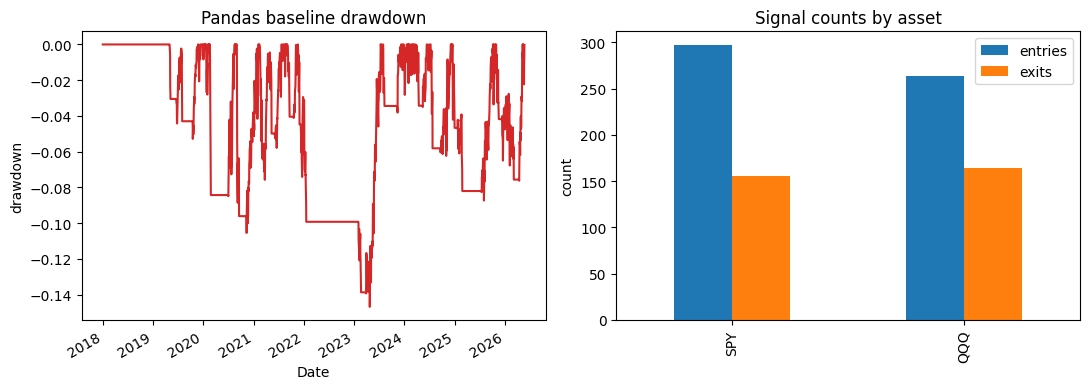

In [3]:
drawdown = pandas_result.equity / pandas_result.equity.cummax() - 1.0
signal_counts = pd.DataFrame({"entries": entries.sum(), "exits": exits.sum()})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
drawdown.plot(ax=axes[0], color="tab:red", title="Pandas baseline drawdown")
signal_counts.plot(kind="bar", ax=axes[1], title="Signal counts by asset")
axes[0].set_ylabel("drawdown")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()


In [4]:
from examples.quant_trading.frameworks import (
    run_vectorbt_from_signals,
    run_bt_target_weights,
    run_backtestingpy_signal,
    write_framework_templates,
    quantstats_html_report,
)

template_paths = write_framework_templates(Path("examples/quant_trading/templates"))
pd.DataFrame({"template": [path.as_posix() for path in template_paths]})

,template
0,examples/quant_trading/templates/backtrader_de...
1,examples/quant_trading/templates/zipline_reloa...


In [5]:
# Optional examples after installing the relevant packages:
# vectorbt_portfolio = run_vectorbt_from_signals(prices, entries, exits)
# quantstats_html_report(pandas_result.returns, Path("examples/quant_trading/reports/tear_sheet.html"))